In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
import os
import cv2

In [2]:
#Can only try 4,5 or 6 for i

i=0
#files=sorted(glob("/home/abubakr/Desktop/*sync*csv"))
#files=sorted(glob("processed_data/*26*/"+str(i)+"*/*sync*csv"))
files=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/SBS_orientations/*/*/*.csv"))
#files=sorted(glob("/home/*/Desktop/FLS_data_corrected_0_1_diff/*sync*csv"))
files

['/home/saab/Desktop/2024_UWR/Analysis/SBS_orientations/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/P_data_expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/SBS_orientations/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/confidence_case_expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/SBS_orientations/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag/output_case_expt7_not_straight_wall_3_Q_0.1_R_10_2026_03_17_17_27_09.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/SBS_orientations/expt7_not_straight_wall_3_Q_1_R_10_2026_03_17_16_15_01.bag/expt7_not_straight_wall_3_Q_1_R_10_2026_03_17_16_15_01.bag_0/P_data_expt7_not_straight_wall_3_Q_1_R_10_2026_03_17_1

In [11]:
#df1_st=pd.read_csv(files[0])
df1_nt_st=pd.read_csv(files[2])
df1_nt_st_confidence=pd.read_csv(files[1])

In [12]:
#df1_st=pd.read_csv(files[0])
df2_nt_st=pd.read_csv(files[11])
df2_nt_st_confidence=pd.read_csv(files[10])

In [13]:
df1_nt_st["Timestamp"]=df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]

In [17]:
df2_nt_st

,Timestamp,IMU_Linear_Acc_X,IMU_Linear_Acc_Y,IMU_Linear_Acc_Z,Filtered_X,Filtered_Y,Filtered_Z,Pose_X,Pose_Y,Pose_Z
0,1.773733e+09,0.03353,0.01916,9.80042,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,1.773733e+09,0.03353,0.00000,9.80042,0.000000e+00,-1.721514e-08,0.000000e+00,0.000000e+00,-3.424902e-12,0.000000e+00
2,1.773733e+09,0.00958,0.01916,9.80042,-2.151892e-08,-1.348948e-07,0.000000e+00,-1.112025e-14,-3.843716e-12,0.000000e+00
3,1.773733e+09,0.04790,0.00479,9.80521,-1.557071e-07,-5.385934e-07,4.304024e-09,5.188699e-01,7.284136e-01,9.438395e-13
4,1.773733e+09,0.03832,0.00000,9.80521,-5.516277e-07,-1.519772e-06,3.802960e-08,5.195422e-01,7.293574e-01,1.215895e-11
...,...,...,...,...,...,...,...,...,...,...
2743,1.773733e+09,0.00958,-0.02395,9.80521,-2.357554e-02,-1.383777e-02,-5.196296e-05,2.667491e+00,2.686261e+00,-1.686113e-07
2744,1.773733e+09,0.00000,-0.00479,9.79563,-2.429455e-02,-1.434645e-02,-2.115759e-05,2.667494e+00,2.686259e+00,-1.736959e-07
2745,1.773733e+09,0.00000,-0.00958,9.78605,-2.499535e-02,-1.486482e-02,1.157199e-05,2.667497e+00,2.686256e+00,-1.787740e-07
2746,1.773733e+09,0.00000,-0.02395,9.80042,-2.567576e-02,-1.539210e-02,4.568469e-05,2.667545e+00,2.686206e+00,-2.714683e-07


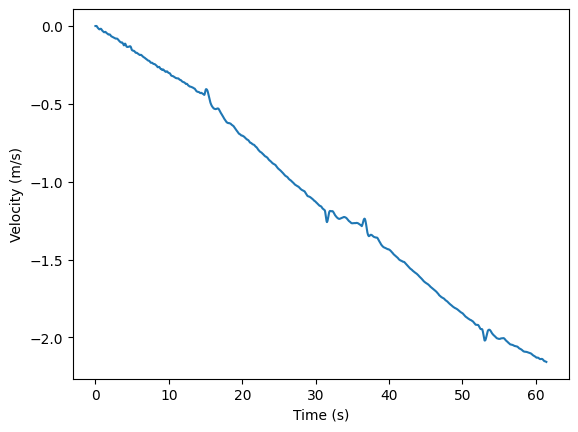

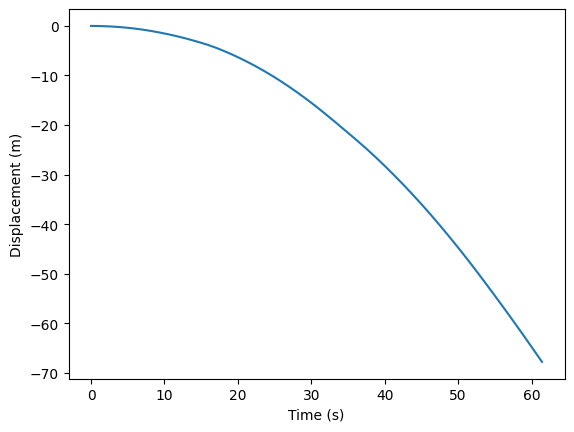

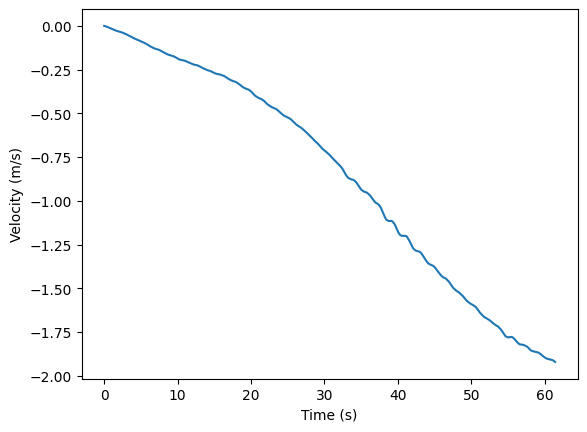

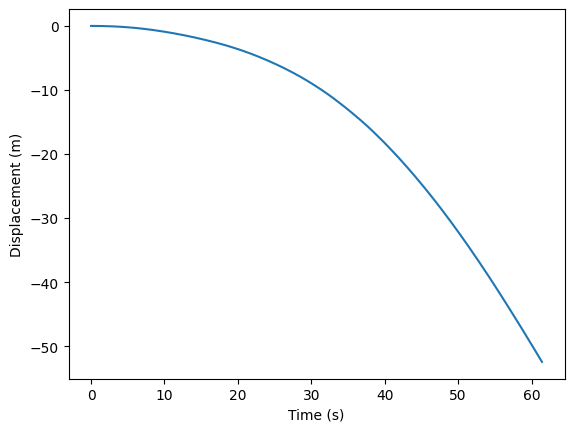

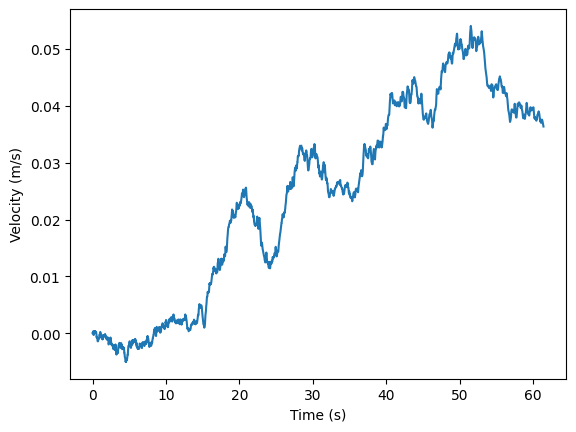

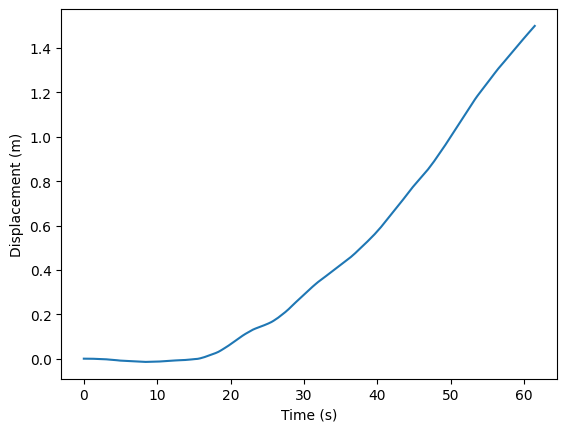

In [21]:
def create_v_d(accs,imus):
    vels=[]
    prev_time=imus.iloc[0]["Timestamp"]
    bias=imus.iloc[0][accs]
    prev_acc=0
    prev_vel=0
    for x in imus.iloc:
    
            #Avg acc * dt = dv
        vel_d=0.5*(prev_acc+x[accs]-2*bias)*(x["Timestamp"]-prev_time)
        #vel=vel_d
        vel=prev_vel+vel_d
        prev_vel=vel
        prev_time=x["Timestamp"]
        prev_acc=x[accs]
        vels.append(vel)
    plt.figure()
    plt.ylabel("Velocity (m/s)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]),vels)
    i=0
    prev_s=0
    prev_v=0
    prev_time=imus.iloc[0]["Timestamp"]
    dists=[]
    for x in imus.iloc:
    
            #Avg acc * dt = dv
        s=prev_s+vels[i]*(x["Timestamp"]-prev_time)+0.5*0.5*(prev_acc+x[accs]-2*bias)*np.square(x["Timestamp"]-prev_time)
        #s=prev_s+(vels[i])*(x["Timestamp"]-prev_time)
        prev_s=s
        prev_vel=vels[i]
        prev_acc=x[accs]
        prev_time=x["Timestamp"]
        dists.append(s)
        i+=1
    plt.figure()
    plt.ylabel("Displacement (m)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),dists)
    return vels,dists
#z_v,z_d=create_v_d("IMU_Raw_z",df2)
#y_v,y_d=create_v_d("IMU_Raw_y",df2)
#x_v,x_d=create_v_d("IMU_Raw_x",df2)
#z_v_st,z_d_st=create_v_d("IMU_Linear_Acc_Z",df2_st)
#y_v_st,y_d_st=create_v_d("IMU_Linear_Acc_Y",df2_st)
#x_v_st,x_d_st=create_v_d("IMU_Linear_Acc_X",df2_st)
x_v_nt_st,x_d_nt_st=create_v_d("IMU_Linear_Acc_X",df1_nt_st)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_Y",df1_nt_st)

z_v_nt_st,z_d_nt_st=create_v_d("IMU_Linear_Acc_Z",df1_nt_st)

In [ ]:
df1_nt_st["Pose"]

Text(0.5, 1.0, 'Comparison of New and Old Tuning')

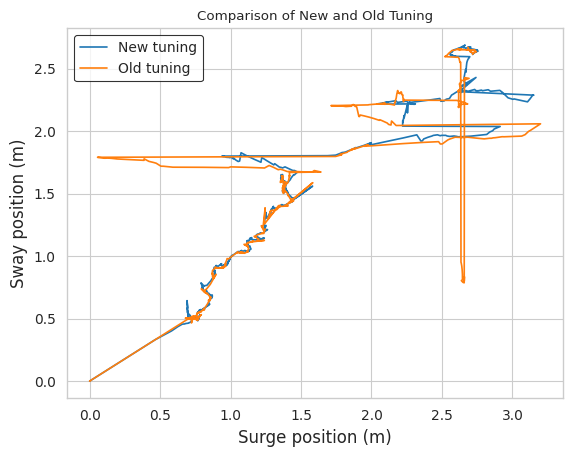

In [161]:
plt.plot(df1_nt_st["Pose_Y"],df1_nt_st["Pose_X"],label="New tuning")
plt.plot(df2_nt_st["Pose_Y"],df2_nt_st["Pose_X"],label="Old tuning")
plt.legend()
plt.xlabel("Surge position (m)")
plt.ylabel("Sway position (m)")
plt.title("Comparison of New and Old Tuning")

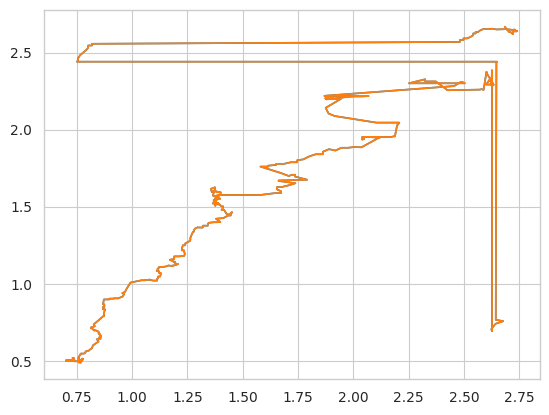

In [ ]:

plt.plot(df1_nt_st_confidence["Sonar_distance_2"],df1_nt_st_confidence["Sonar_distance_1"])

In [142]:
angle=45

In [143]:
plt.plot(np.array(x_d_st)*np.cos(np.deg2rad(angle))-np.array(y_d_st)*np.sin(np.deg2rad(angle)))

NameError: name 'x_d_st' is not defined

In [144]:
plt.plot(np.array(x_d_st)*np.sin(np.deg2rad(angle))+np.array(y_d_st)*np.cos(np.deg2rad(angle)))

NameError: name 'x_d_st' is not defined

In [145]:
import matplotlib.patches as patches
def plot_ellipses(ax, df):
    for idx, row in df.iterrows():
        # Confidence for color intensity, using the average of x and y confidence

        width = 1*(1-(row['Confidence_1']) / 100)
        height =1*(1-(row['Confidence_2']) / 100)

        
        # Draw ellipse to represent confidence in x and y
        ellipse = patches.Ellipse((row['Sonar_Distance_1']-df["Sonar_Distance_1"][0], row['Sonar_Distance_2']-df["Sonar_Distance_2"][0]), width, height,
                                  color=(1, 0.84, 0, 0.1), fill=True)
        ax.add_patch(ellipse)

NameError: name 'df1_st' is not defined

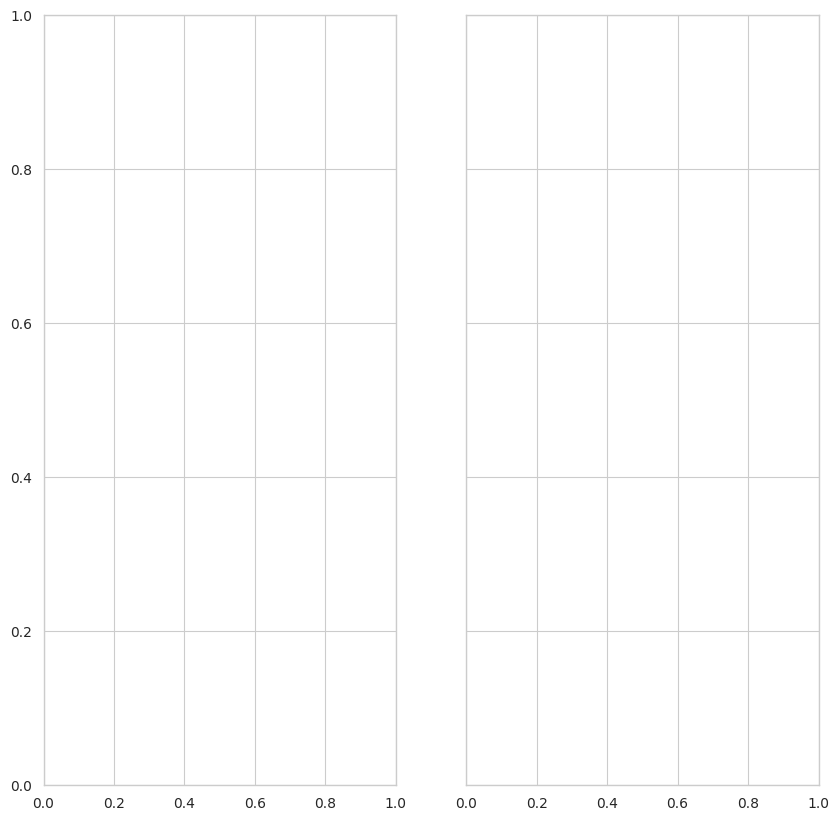

In [146]:
fig, ax = plt.subplots(1,2,figsize=(10, 10),sharey=True)
s=3
gt_2dof_st=np.linspace(0,2,len(df1_st))
ax[0].scatter(df1_st["Pose_X"] - df1_st["Pose_X"][0], df1_st["Pose_Y"] - df1_st["Pose_Y"][0], color='turquoise', label='KF position',marker="*",s=s)
ax[0].scatter(df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"][0], df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"][0], color='gold', label='SBS position',s=s)
ax[0].scatter(gt_2dof_st, gt_2dof_st, color='black', label='Ground truth position',s=s)
ax[0].scatter(1*np.array(x_d_st),1*np.array(y_d_st),label="IMU position" , color='magenta',s=s)
# Plot ellipses
plot_ellipses(ax[0], df1_st)

gt_2dof_nt_st=np.linspace(0,np.sqrt(2),len(df1_nt_st))
ax[1].scatter(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0], df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0], color='turquoise', label='KF position',marker="*",s=s)
ax[1].scatter(df1_nt_st["Sonar_Distance_1"] - df1_nt_st["Sonar_Distance_1"][0], df1_nt_st["Sonar_Distance_2"] - df1_nt_st["Sonar_Distance_2"][0], color='gold', label='SBS position',s=s)
ax[1].scatter(gt_2dof_nt_st, gt_2dof_nt_st, color='black', label='Ground truth position',s=s)
ax[1].scatter(1*np.array(x_d_nt_st),1*np.array(y_d_nt_st),label="IMU position", color='magenta',s=s)
# Plot ellipses
plot_ellipses(ax[1], df1_nt_st)

# Set aspect to equal for correct distance representation
ax[0].set_xlim([-1, 2.5])
ax[0].set_ylim([-1, 2.5])
ax[1].set_xlim([-1, 2.5])
ax[1].set_ylim([-1, 2.5])
ax[0].grid(True)
ax[1].grid(True)
# Add legend
ax[0].legend()
ax[1].legend()
ax[0].set_title("Not aligned to walls")
ax[1].set_title("Aligned to walls")
ax[0].set_xlabel("X position (m)")
ax[1].set_xlabel("X position (m)")
ax[0].set_ylabel("Y position (m)")
#plt.title("Movement when SBS is aligned to a wall")
plt.tight_layout()
plt.show()

In [147]:
df1_nt_st_confidence["Sonar_distance_1"]=df1_nt_st_confidence["Sonar_distance_1"]/1000
df1_nt_st_confidence["Sonar_distance_2"]=df1_nt_st_confidence["Sonar_distance_2"]/1000

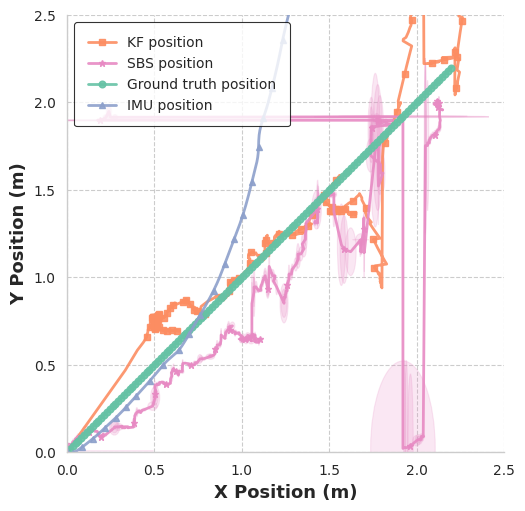

In [148]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# --- Seaborn theme for thesis-quality plots ---
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
fig2, ax2 = plt.subplots(figsize=figsize, constrained_layout=True)
def plot_ellipses(ax, df):
    for idx, row in df.iterrows():
        width = 1 * (1 - row['Confidence_1'] / 100)
        height = 1 * (1 - row['Confidence_2'] / 100)
        ellipse = patches.Ellipse(
            (row['Sonar_distance_1'] - df["Sonar_distance_1"][0],
             row['Sonar_distance_2'] - df["Sonar_distance_2"][0]),
            width, height,
            color=palette[3], alpha=0.2
        )
        ax.add_patch(ellipse)

# --- Plot settings ---
figsize = (7, 5)  # square, compact, thesis-style
s = 8  # marker size
xlim = [0, 2.5]
ylim = [0, 2.5]
gt_2dof_nt_st = np.linspace(0, 2.2, len(df1_nt_st))

ax2.plot(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0],
            df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0],
            color=palette[1], label='KF position', marker=markers[1],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(df1_nt_st_confidence["Sonar_distance_1"] - df1_nt_st_confidence["Sonar_distance_1"][0],
            df1_nt_st_confidence["Sonar_distance_2"] - df1_nt_st_confidence["Sonar_distance_2"][0],
            color=palette[3], label='SBS position', marker=markers[3],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(gt_2dof_nt_st, gt_2dof_nt_st,
            color=palette[0], label='Ground truth position', marker=markers[0],
        markevery=20,linewidth=2,
        alpha=0.9)

ax2.plot(-np.array(x_d_nt_st), -np.array(y_d_nt_st),
            color=palette[2], label='IMU position', marker=markers[2],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.4, color='gray')
plot_ellipses(ax2, df1_nt_st_confidence)
sns.despine()
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_aspect('equal')
ax2.set_xlabel("X Position (m)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Y Position (m)", fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', frameon=True, fancybox=False)

ax2.legend(
    fontsize=10,
    loc='upper left',
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black'
)

plt.show()

In [149]:
import numpy as np

def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

def rmse_vs_linear_gt(pred, gt_len, gt_start=0.0, gt_end=1.0, pred_times=None):
    """
    Compare pred to a ground-truth path defined as a linear ramp [gt_start..gt_end] of length gt_len.
    If pred length != gt_len, we interpolate the GT to pred using pred_times if provided (timestamps),
    otherwise we interpolate by index.
    """
    pred = np.asarray(pred)
    gt = np.linspace(gt_start, gt_end, gt_len)

    if pred.shape[0] == gt.shape[0]:
        return rmse(pred, gt)

    # Try timestamp-based interpolation if times provided
    if pred_times is not None:
        pred_times = np.asarray(pred_times, dtype=float)
        # normalized times for GT (0..1)
        gt_time = np.linspace(0.0, 1.0, gt_len)
        pred_time_norm = (pred_times - pred_times[0]) / (pred_times[-1] - pred_times[0]) if pred_times[-1] != pred_times[0] else np.linspace(0,1,len(pred))
        gt_interp = np.interp(pred_time_norm, gt_time, gt)
        return rmse(pred, gt_interp)

    # fallback: index-based interpolation
    gt_interp = np.interp(np.linspace(0, gt_len - 1, pred.shape[0]), np.arange(gt_len), gt)
    return rmse(pred, gt_interp)

# --- Parameters used in the plot earlier ---
# For aligned ("nt_st") plot the notebook used:
gt_nt_start = 0.0
gt_nt_end = 2.2
gt_nt_len = len(df1_nt_st)

# Prepare predicted series (X and Y)
kf_x_nt = (df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"].iloc[0]).to_numpy()
kf_y_nt = (df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"].iloc[0]).to_numpy()

# SBS uses df1_nt_st_confidence with lower-case Sonar_distance_1/2 in your plotting code
sbs_x_nt = (df1_nt_st_confidence["Sonar_distance_1"] - df1_nt_st_confidence["Sonar_distance_1"].iloc[0]).to_numpy()
sbs_y_nt = (df1_nt_st_confidence["Sonar_distance_2"] - df1_nt_st_confidence["Sonar_distance_2"].iloc[0]).to_numpy()

# IMU predictions used in plot: note you negated them in plot
imu_x_nt = -np.array(x_d_nt_st)
imu_y_nt = -np.array(y_d_nt_st)

# Optionally provide timestamp arrays for interpolation if available
kf_times = (df1_nt_st["Timestamp"] - df1_nt_st["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in df1_nt_st.columns else None
sbs_times = (df1_nt_st_confidence["Timestamp"] - df1_nt_st_confidence["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in df1_nt_st_confidence.columns else None
# For IMU arrays timestamps may be in df2_nt_st
imu_times = (df2_nt_st["Timestamp"] - df2_nt_st["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in locals() and "Timestamp" in df2_nt_st.columns else None

# Compute RMSEs (aligned case)
print("Aligned (nt_st) RMSEs vs ground truth ramp [0..2.2]:")
print(" KF X RMSE:  ", rmse_vs_linear_gt(kf_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=kf_times))
print(" KF Y RMSE:  ", rmse_vs_linear_gt(kf_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=kf_times))
print(" SBS X RMSE: ", rmse_vs_linear_gt(sbs_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=sbs_times))
print(" SBS Y RMSE: ", rmse_vs_linear_gt(sbs_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=sbs_times))
print(" IMU X RMSE: ", rmse_vs_linear_gt(imu_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=imu_times))
print(" IMU Y RMSE: ", rmse_vs_linear_gt(imu_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=imu_times))

# --- (Optional) If you want the not-aligned (st) case too ---
if 'df1_st' in globals():
    gt_st_start = 0.0
    gt_st_end = 2.0
    gt_st_len = len(df1_st)
    kf_x_st = (df1_st["Pose_X"] - df1_st["Pose_X"].iloc[0]).to_numpy()
    kf_y_st = (df1_st["Pose_Y"] - df1_st["Pose_Y"].iloc[0]).to_numpy()
    sbs_x_st = (df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"].iloc[0]).to_numpy()
    sbs_y_st = (df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"].iloc[0]).to_numpy()
    print("\nNot-aligned (st) RMSEs vs ground truth ramp [0..2.0]:")
    print(" KF X RMSE:  ", rmse_vs_linear_gt(kf_x_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" KF Y RMSE:  ", rmse_vs_linear_gt(kf_y_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" SBS X RMSE: ", rmse_vs_linear_gt(sbs_x_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" SBS Y RMSE: ", rmse_vs_linear_gt(sbs_y_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))

Aligned (nt_st) RMSEs vs ground truth ramp [0..2.2]:
 KF X RMSE:   0.29767252653107085
 KF Y RMSE:   0.38260674754880036
 SBS X RMSE:  0.35406965804262075
 SBS Y RMSE:  0.45558496752850147
 IMU X RMSE:  1.037180401249437
 IMU Y RMSE:  3.6275559999840676


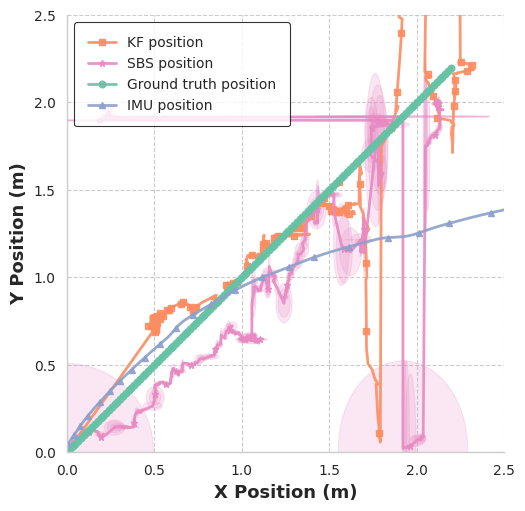

In [120]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# --- Seaborn theme for thesis-quality plots ---
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
fig2, ax2 = plt.subplots(figsize=figsize, constrained_layout=True)
def plot_ellipses(ax, df):
    for idx, row in df.iterrows():
        width = 1 * (1 - row['Confidence_1'] / 100)
        height = 1 * (1 - row['Confidence_2'] / 100)
        ellipse = patches.Ellipse(
            (row['Sonar_distance_1'] - df["Sonar_distance_1"][0],
             row['Sonar_distance_2'] - df["Sonar_distance_2"][0]),
            width, height,
            color=palette[3], alpha=0.2
        )
        ax.add_patch(ellipse)

# --- Plot settings ---
figsize = (7, 5)  # square, compact, thesis-style
s = 8  # marker size
xlim = [0, 2.5]
ylim = [0, 2.5]
gt_2dof_nt_st = np.linspace(0, 2.2, len(df1_nt_st))

ax2.plot(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0],
            df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0],
            color=palette[1], label='KF position', marker=markers[1],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(df1_nt_st_confidence["Sonar_distance_1"] - df1_nt_st_confidence["Sonar_distance_1"][0],
            df1_nt_st_confidence["Sonar_distance_2"] - df1_nt_st_confidence["Sonar_distance_2"][0],
            color=palette[3], label='SBS position', marker=markers[3],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(gt_2dof_nt_st, gt_2dof_nt_st,
            color=palette[0], label='Ground truth position', marker=markers[0],
        markevery=20,linewidth=2,
        alpha=0.9)

ax2.plot(-np.array(y_d_nt_st), -np.array(x_d_nt_st),
            color=palette[2], label='IMU position', marker=markers[2],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.4, color='gray')
plot_ellipses(ax2, df1_nt_st_confidence)
sns.despine()
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_aspect('equal')
ax2.set_xlabel("X Position (m)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Y Position (m)", fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', frameon=True, fancybox=False)

ax2.legend(
    fontsize=10,
    loc='upper left',
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black'
)

plt.show()

In [121]:
import numpy as np

def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

def rmse_vs_linear_gt(pred, gt_len, gt_start=0.0, gt_end=1.0, pred_times=None):
    """
    Compare pred to a ground-truth path defined as a linear ramp [gt_start..gt_end] of length gt_len.
    If pred length != gt_len, we interpolate the GT to pred using pred_times if provided (timestamps),
    otherwise we interpolate by index.
    """
    pred = np.asarray(pred)
    gt = np.linspace(gt_start, gt_end, gt_len)

    if pred.shape[0] == gt.shape[0]:
        return rmse(pred, gt)

    # Try timestamp-based interpolation if times provided
    if pred_times is not None:
        pred_times = np.asarray(pred_times, dtype=float)
        # normalized times for GT (0..1)
        gt_time = np.linspace(0.0, 1.0, gt_len)
        pred_time_norm = (pred_times - pred_times[0]) / (pred_times[-1] - pred_times[0]) if pred_times[-1] != pred_times[0] else np.linspace(0,1,len(pred))
        gt_interp = np.interp(pred_time_norm, gt_time, gt)
        return rmse(pred, gt_interp)

    # fallback: index-based interpolation
    gt_interp = np.interp(np.linspace(0, gt_len - 1, pred.shape[0]), np.arange(gt_len), gt)
    return rmse(pred, gt_interp)

# --- Parameters used in the plot earlier ---
# For aligned ("nt_st") plot the notebook used:
gt_nt_start = 0.0
gt_nt_end = 2.2
gt_nt_len = len(df1_nt_st)

# Prepare predicted series (X and Y)
kf_x_nt = (df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"].iloc[0]).to_numpy()
kf_y_nt = (df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"].iloc[0]).to_numpy()

# SBS uses df1_nt_st_confidence with lower-case Sonar_distance_1/2 in your plotting code
sbs_x_nt = (df1_nt_st_confidence["Sonar_distance_1"] - df1_nt_st_confidence["Sonar_distance_1"].iloc[0]).to_numpy()
sbs_y_nt = (df1_nt_st_confidence["Sonar_distance_2"] - df1_nt_st_confidence["Sonar_distance_2"].iloc[0]).to_numpy()

# IMU predictions used in plot: note you negated them in plot
imu_x_nt = -np.array(x_d_nt_st)
imu_y_nt = -np.array(y_d_nt_st)

# Optionally provide timestamp arrays for interpolation if available
kf_times = (df1_nt_st["Timestamp"] - df1_nt_st["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in df1_nt_st.columns else None
sbs_times = (df1_nt_st_confidence["Timestamp"] - df1_nt_st_confidence["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in df1_nt_st_confidence.columns else None
# For IMU arrays timestamps may be in df2_nt_st
imu_times = (df2_nt_st["Timestamp"] - df2_nt_st["Timestamp"].iloc[0]).to_numpy() if "Timestamp" in locals() and "Timestamp" in df2_nt_st.columns else None

# Compute RMSEs (aligned case)
print("Aligned (nt_st) RMSEs vs ground truth ramp [0..2.2]:")
print(" KF X RMSE:  ", rmse_vs_linear_gt(kf_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=kf_times))
print(" KF Y RMSE:  ", rmse_vs_linear_gt(kf_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=kf_times))
print(" SBS X RMSE: ", rmse_vs_linear_gt(sbs_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=sbs_times))
print(" SBS Y RMSE: ", rmse_vs_linear_gt(sbs_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=sbs_times))
print(" IMU X RMSE: ", rmse_vs_linear_gt(imu_y_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=imu_times))
print(" IMU Y RMSE: ", rmse_vs_linear_gt(imu_x_nt, gt_len=gt_nt_len, gt_start=gt_nt_start, gt_end=gt_nt_end, pred_times=imu_times))

# --- (Optional) If you want the not-aligned (st) case too ---
if 'df1_st' in globals():
    gt_st_start = 0.0
    gt_st_end = 2.0
    gt_st_len = len(df1_st)
    kf_x_st = (df1_st["Pose_X"] - df1_st["Pose_X"].iloc[0]).to_numpy()
    kf_y_st = (df1_st["Pose_Y"] - df1_st["Pose_Y"].iloc[0]).to_numpy()
    sbs_x_st = (df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"].iloc[0]).to_numpy()
    sbs_y_st = (df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"].iloc[0]).to_numpy()
    print("\nNot-aligned (st) RMSEs vs ground truth ramp [0..2.0]:")
    print(" KF X RMSE:  ", rmse_vs_linear_gt(kf_x_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" KF Y RMSE:  ", rmse_vs_linear_gt(kf_y_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" SBS X RMSE: ", rmse_vs_linear_gt(sbs_x_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))
    print(" SBS Y RMSE: ", rmse_vs_linear_gt(sbs_y_st, gt_len=gt_st_len, gt_start=gt_st_start, gt_end=gt_st_end))

Aligned (nt_st) RMSEs vs ground truth ramp [0..2.2]:
 KF X RMSE:   0.31715190387260017
 KF Y RMSE:   0.3872825929654889
 SBS X RMSE:  0.35406844338321164
 SBS Y RMSE:  0.45558239961394775
 IMU X RMSE:  3.73203040076559
 IMU Y RMSE:  1.1040165138999194


NameError: name 'df1_st' is not defined

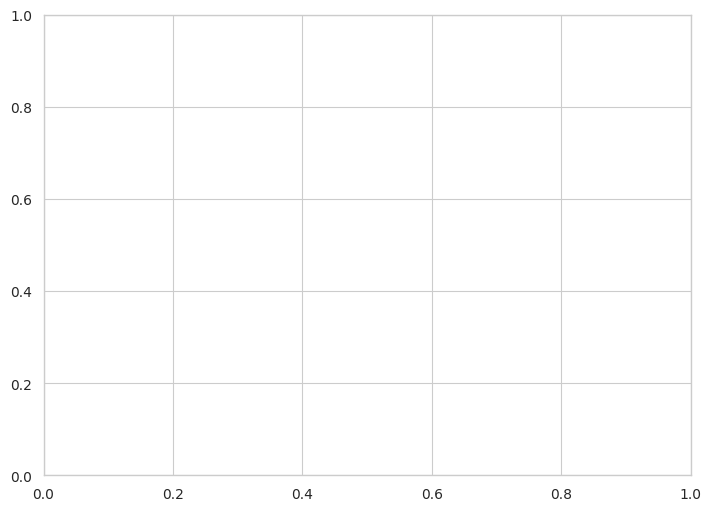

In [115]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# --- Seaborn theme for thesis-quality plots ---
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})

def plot_ellipses(ax, df):
    for idx, row in df.iterrows():
        width = 1 * (1 - row['Confidence_1'] / 100)
        height = 1 * (1 - row['Confidence_2'] / 100)
        ellipse = patches.Ellipse(
            (row['Sonar_Distance_1'] - df["Sonar_Distance_1"][0],
             row['Sonar_Distance_2'] - df["Sonar_Distance_2"][0]),
            width, height,
            color=palette[1], alpha=0.2
        )
        ax.add_patch(ellipse)

# --- Plot settings ---
figsize = (7, 5)  # square, compact, thesis-style
s = 8  # marker size
xlim = [0, 2.5]
ylim = [0, 2.5]

# --- Plot 1: Not aligned to walls ---
fig1, ax1 = plt.subplots(figsize=figsize, constrained_layout=True)

gt_2dof_st = np.linspace(0, 2, len(df1_st))
ax1.plot(df1_st["Pose_X"] - df1_st["Pose_X"][0],
            df1_st["Pose_Y"] - df1_st["Pose_Y"][0],
            color=palette[1], label='KF position', marker=markers[1],
        markevery=20)
ax1.plot(df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"][0],
            df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"][0],
            color=palette[3], label='SBS position', marker=markers[3],
        markevery=20,linewidth=2,
        alpha=0.9,)
ax1.plot(gt_2dof_st, gt_2dof_st,
            color=palette[0], label='Ground truth position', marker=markers[0],
        markevery=20,linewidth=2,
        alpha=0.9)
ax1.plot(np.array(x_d_st), np.array(y_d_st),
            color=palette[2], label='IMU position',marker=markers[2],
        markevery=20,linewidth=2,
        alpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')
sns.despine()
plot_ellipses(ax1, df1_st)

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_aspect('equal')
ax1.set_xlabel("X Position (m)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Y Position (m)", fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', frameon=True, fancybox=False)

ax1.legend(
    fontsize=10,
    loc='upper left',
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black'
)

# --- Plot 2: Aligned to walls ---
fig2, ax2 = plt.subplots(figsize=figsize, constrained_layout=True)

gt_2dof_nt_st = np.linspace(0, np.sqrt(2), len(df1_nt_st))
ax2.plot(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0],
            df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0],
            color=palette[1], label='KF position', marker=markers[1],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(df1_nt_st["Sonar_Distance_1"] - df1_nt_st["Sonar_Distance_1"][0],
            df1_nt_st["Sonar_Distance_2"] - df1_nt_st["Sonar_Distance_2"][0],
            color=palette[3], label='SBS position', marker=markers[3],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(gt_2dof_nt_st, gt_2dof_nt_st,
            color=palette[0], label='Ground truth position', marker=markers[0],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.plot(np.array(x_d_nt_st), np.array(y_d_nt_st),
            color=palette[2], label='IMU position', marker=markers[2],
        markevery=20,linewidth=2,
        alpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.4, color='gray')
plot_ellipses(ax2, df1_nt_st)
sns.despine()
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_aspect('equal')
ax2.set_xlabel("X Position (m)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Y Position (m)", fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', frameon=True, fancybox=False)

ax2.legend(
    fontsize=10,
    loc='upper left',
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black'
)

plt.show()

NameError: name 'df1_st' is not defined

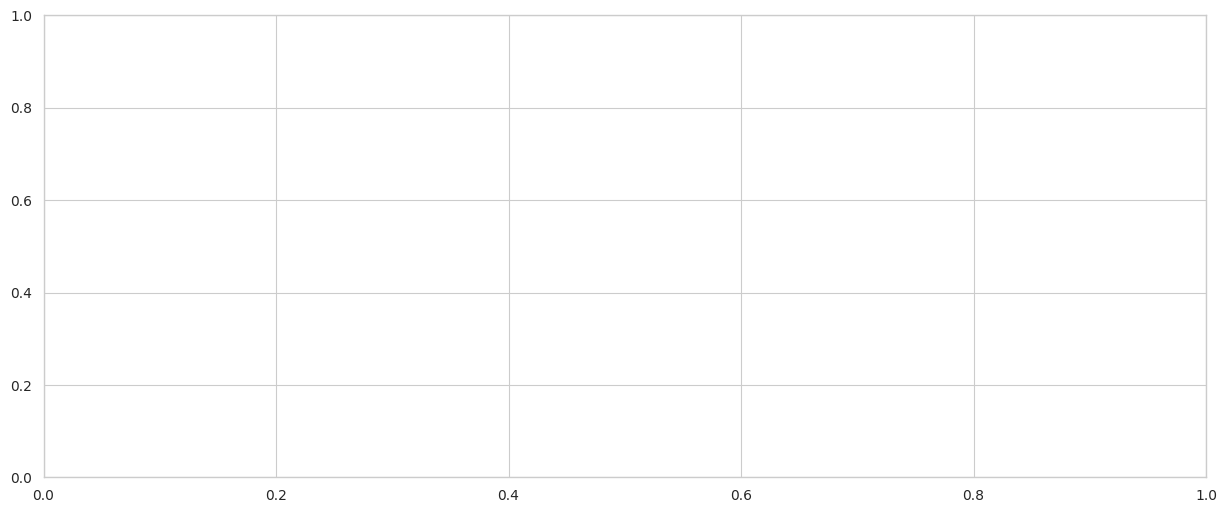

In [116]:
import matplotlib.pyplot as plt
import numpy as np

s = 5  # slightly larger marker size for clarity

# --- First Figure: Not aligned to walls ---
fig1, ax1 = plt.subplots(figsize=(15, 6))

gt_2dof_st = np.linspace(0, 2, len(df1_st))
ax1.scatter(df1_st["Pose_X"] - df1_st["Pose_X"][0], 
            df1_st["Pose_Y"] - df1_st["Pose_Y"][0], 
            color='turquoise', label='KF position', marker="*", s=s)
ax1.scatter(df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"][0], 
            df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"][0], 
            color='gold', label='SBS position', s=s)
ax1.scatter(gt_2dof_st, gt_2dof_st, 
            color='black', label='Ground truth position', s=s)
ax1.scatter(np.array(x_d_st), np.array(y_d_st), 
            label="IMU position", color='magenta', s=s)

plot_ellipses(ax1, df1_st)

ax1.set_xlim([-1, 2.5])
ax1.set_ylim([-1, 2.5])
ax1.set_aspect('equal')
ax1.grid(True)
ax1.legend()
ax1.set_title("Not Aligned to Walls")
ax1.set_xlabel("X Position (m)")
ax1.set_ylabel("Y Position (m)")

plt.tight_layout()
plt.show()

# --- Second Figure: Aligned to walls ---
fig2, ax2 = plt.subplots(figsize=(6, 6))

gt_2dof_nt_st = np.linspace(0, np.sqrt(2), len(df1_nt_st))
ax2.scatter(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0], 
            df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0], 
            color='turquoise', label='KF position', marker="*", s=s)
ax2.scatter(df1_nt_st["Sonar_Distance_1"] - df1_nt_st["Sonar_Distance_1"][0], 
            df1_nt_st["Sonar_Distance_2"] - df1_nt_st["Sonar_Distance_2"][0], 
            color='gold', label='SBS position', s=s)
ax2.scatter(gt_2dof_nt_st, gt_2dof_nt_st, 
            color='black', label='Ground truth position', s=s)
ax2.scatter(np.array(x_d_nt_st), np.array(y_d_nt_st), 
            label="IMU position", color='magenta', s=s)

plot_ellipses(ax2, df1_nt_st)

ax2.set_xlim([-1, 2.5])
ax2.set_ylim([-1, 2.5])
ax1.set_aspect('equal')
ax1.grid(True)
ax1.legend()
ax1.set_title("Not Aligned to Walls")
ax1.set_xlabel("X Position (m)")
ax1.set_ylabel("Y Position (m)")


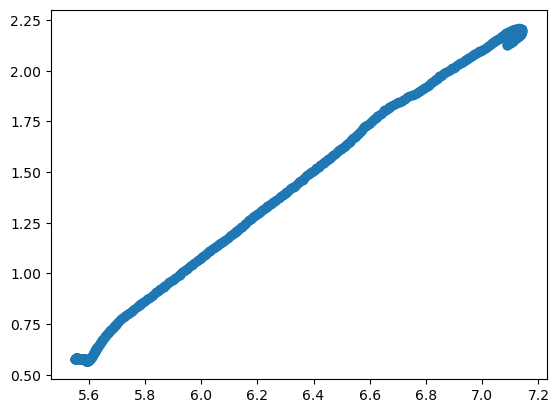

In [37]:
plt.scatter(df1_nt_st["Pose_X"] - df1_st["Pose_X"][0], df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0])

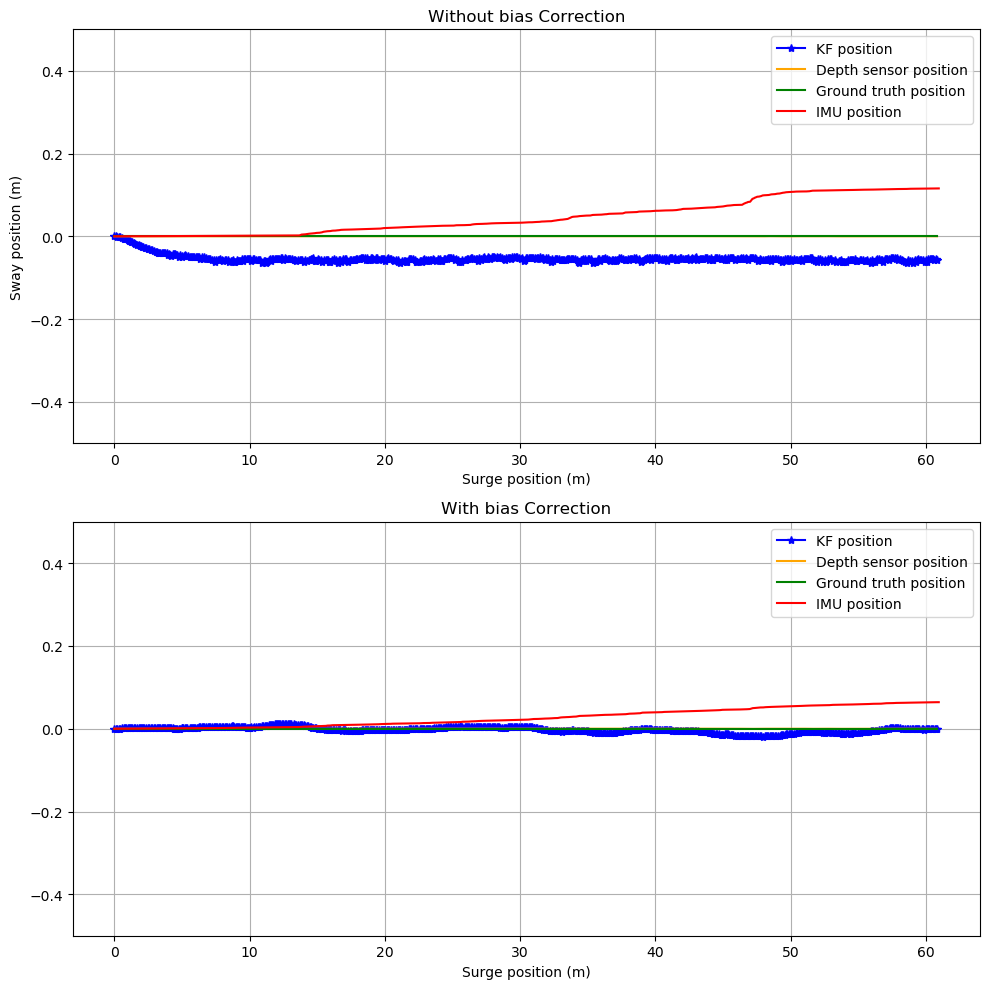

In [37]:
fig, ax = plt.subplots(2,1,figsize=(10, 10),sharey=True)
s=3
gt_2dof_st=np.linspace(0,0,len(df1_st))
ax[0].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), np.array(df1_st["Pose_Z"] - df1_st["Pose_Z"][0]), color='blue', label='KF position',marker="*")
ax[0].plot(np.array(df1_st["Timestamp"] - df1_st["Timestamp"][0]), np.array(df1_st["Depth"] - df1_st["Depth"][0]), color='orange', label='Depth sensor position')
ax[0].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth position')
ax[0].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),1*np.array(x_d_st),label="IMU position" , color='red')
# Plot ellipses


gt_2dof_nt_st=np.linspace(0,0,len(df1_nt_st))
ax[1].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Pose_Z"] - df1_nt_st["Pose_Z"][0]), color='blue', label='KF position',marker="*")
ax[1].plot(np.array(df1_nt_st["Timestamp"] - df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Depth"] - df1_nt_st["Depth"][0]), color='orange', label='Depth sensor position')
ax[1].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), gt_2dof_nt_st, color='green', label='Ground truth position')
ax[1].plot(np.array(df2_nt_st["Timestamp"]-df2_nt_st["Timestamp"][0]),1*np.array(x_d_nt_st),label="IMU position" , color='red')
# Plot ellipses


# Set aspect to equal for correct distance representation
#ax[0].set_xlim([-1, 2.5])
ax[0].set_ylim([-0.5, 0.5])
#ax[1].set_xlim([-1, 2.5])
ax[1].set_ylim([-0.5, 0.5])
ax[0].grid(True)
ax[1].grid(True)
# Add legend
ax[0].legend()
ax[1].legend()
ax[0].set_title("Without bias Correction")
ax[1].set_title("With bias Correction")
ax[0].set_xlabel("Surge position (m)")
ax[1].set_xlabel("Surge position (m)")
ax[0].set_ylabel("Sway position (m)")
#plt.title("Movement when SBS is aligned to a wall")
plt.tight_layout()
plt.show()

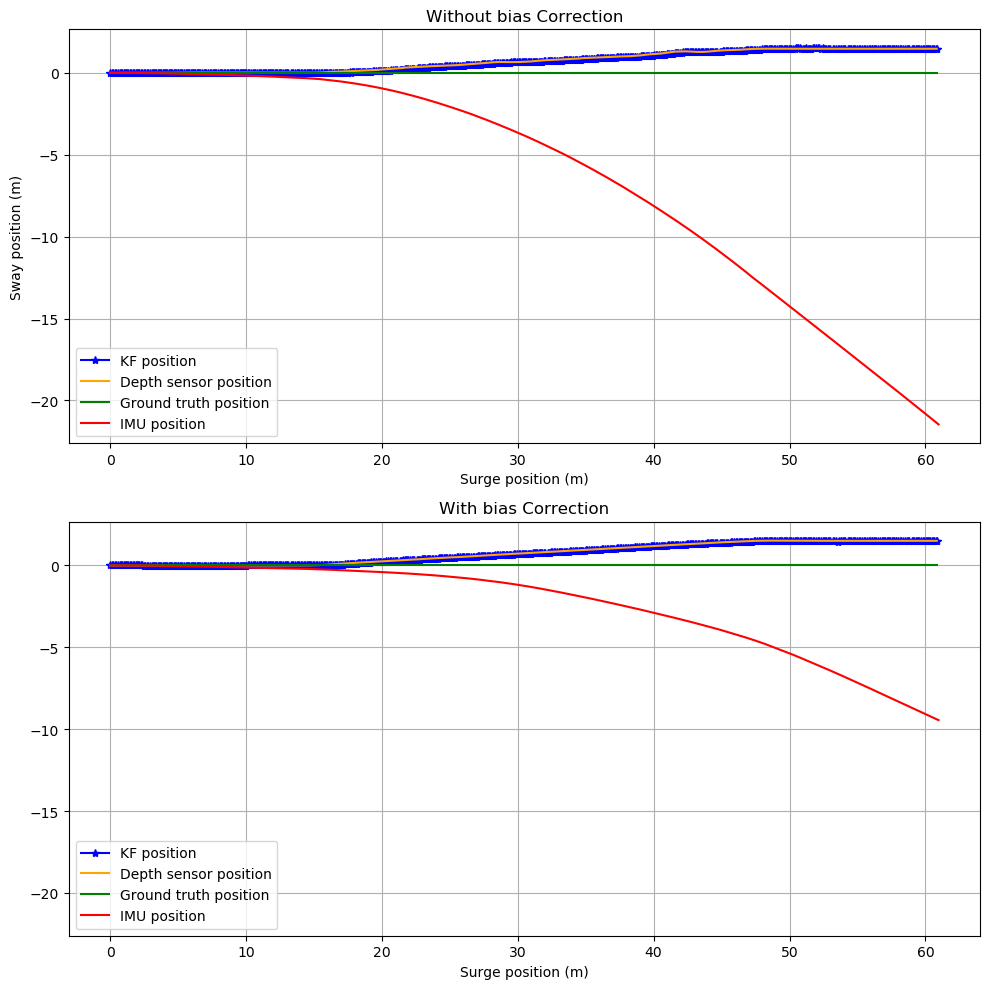

In [154]:
fig, ax = plt.subplots(2,1,figsize=(10, 10),sharey=True)
s=3
gt_2dof_st=np.linspace(0,0,len(df1_st))
ax[0].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), np.array(df1_st["Pose_X"] - df1_st["Pose_X"][0]), color='blue', label='KF position',marker="*")
ax[0].plot(np.array(df1_st["Timestamp"] - df1_st["Timestamp"][0]), np.array(df1_st["Sonar_Distance_1"] - df1_st["Sonar_Distance_1"][0]), color='orange', label='Depth sensor position')
ax[0].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth position')
ax[0].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),1*np.array(x_d_st),label="IMU position" , color='red')
# Plot ellipses


gt_2dof_nt_st=np.linspace(0,0,len(df1_nt_st))
ax[1].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), np.array(df1_st["Pose_Y"] - df1_st["Pose_Y"][0]), color='blue', label='KF position',marker="*")
ax[1].plot(np.array(df1_st["Timestamp"] - df1_st["Timestamp"][0]), np.array(df1_st["Sonar_Distance_2"] - df1_st["Sonar_Distance_2"][0]), color='orange', label='Depth sensor position')
ax[1].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth position')
ax[1].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),1*np.array(y_d_st),label="IMU position" , color='red')
# Plot ellipses


# Set aspect to equal for correct distance representation
#ax[0].set_xlim([-1, 2.5])
#ax[0].set_ylim([-0.5, 0.5])
#ax[1].set_xlim([-1, 2.5])
#ax[1].set_ylim([-0.5, 0.5])
ax[0].grid(True)
ax[1].grid(True)
# Add legend
ax[0].legend()
ax[1].legend()
ax[0].set_title("Without bias Correction")
ax[1].set_title("With bias Correction")
ax[0].set_xlabel("Surge position (m)")
ax[1].set_xlabel("Surge position (m)")
ax[0].set_ylabel("Sway position (m)")
#plt.title("Movement when SBS is aligned to a wall")
plt.tight_layout()
plt.show()

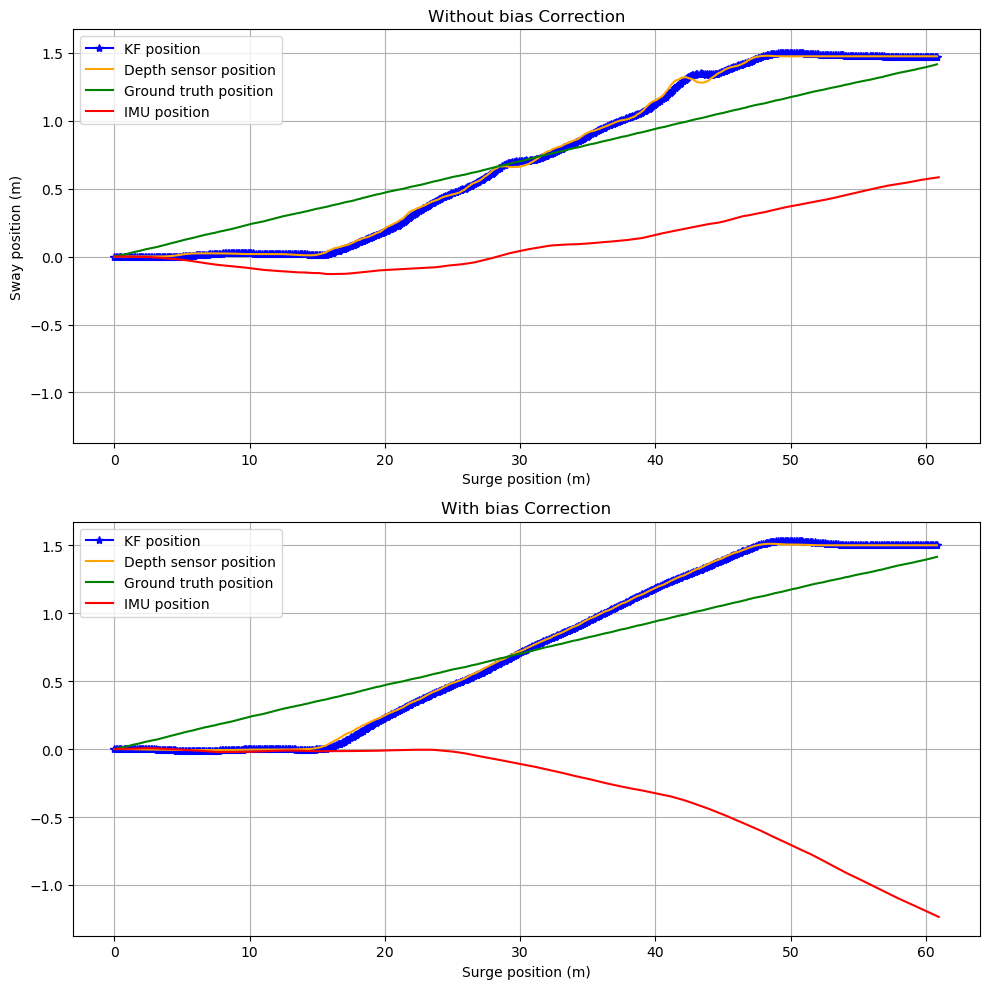

In [153]:
fig, ax = plt.subplots(2,1,figsize=(10, 10),sharey=True)
s=3
gt_2dof_st=np.linspace(0,1.414,len(df1_nt_st))
ax[0].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Pose_X"] - df1_nt_st["Pose_X"][0]), color='blue', label='KF position',marker="*")
ax[0].plot(np.array(df1_nt_st["Timestamp"] - df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Sonar_Distance_1"] - df1_nt_st["Sonar_Distance_1"][0]), color='orange', label='Depth sensor position')
ax[0].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth position')
ax[0].plot(np.array(df2_nt_st["Timestamp"]-df2_nt_st["Timestamp"][0]),1*np.array(x_d_nt_st),label="IMU position" , color='red')
# Plot ellipses


gt_2dof_nt_st=np.linspace(0,1.414,len(df1_nt_st))
ax[1].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Pose_Y"] - df1_nt_st["Pose_Y"][0]), color='blue', label='KF position',marker="*")
ax[1].plot(np.array(df1_nt_st["Timestamp"] - df1_nt_st["Timestamp"][0]), np.array(df1_nt_st["Sonar_Distance_2"] - df1_nt_st["Sonar_Distance_2"][0]), color='orange', label='Depth sensor position')
ax[1].plot(np.array(df1_nt_st["Timestamp"]-df1_nt_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth position')
ax[1].plot(np.array(df2_nt_st["Timestamp"]-df2_nt_st["Timestamp"][0]),1*np.array(y_d_nt_st),label="IMU position" , color='red')
# Plot ellipses


# Set aspect to equal for correct distance representation
#ax[0].set_xlim([-1, 2.5])
#ax[0].set_ylim([-0.5, 0.5])
#ax[1].set_xlim([-1, 2.5])
#ax[1].set_ylim([-0.5, 0.5])
ax[0].grid(True)
ax[1].grid(True)
# Add legend
ax[0].legend()
ax[1].legend()
ax[0].set_title("Without bias Correction")
ax[1].set_title("With bias Correction")
ax[0].set_xlabel("Surge position (m)")
ax[1].set_xlabel("Surge position (m)")
ax[0].set_ylabel("Sway position (m)")
#plt.title("Movement when SBS is aligned to a wall")
plt.tight_layout()
plt.show()

In [28]:
df1_nt_st["Sonar_Distance_1"]

0      6.064
1      6.064
2      6.064
3      6.064
4      6.064
       ...  
602    7.537
603    7.537
604    7.537
605    7.537
606    7.537
Name: Sonar_Distance_1, Length: 607, dtype: float64

ValueError: x and y must have same first dimension, but have shapes (927,) and (931,)

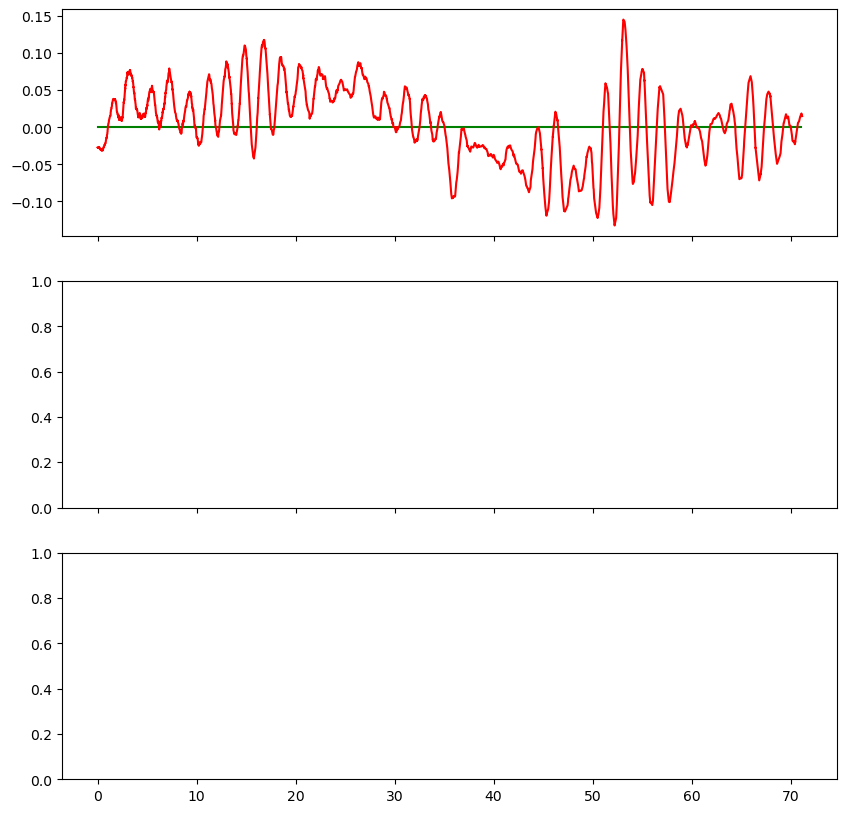

In [39]:
fig, ax = plt.subplots(3,1,figsize=(10, 10),sharex=True)
s=3
gt_2dof_st=np.linspace(0,0,len(df1_st))

from scipy.spatial.transform import Rotation as R

# Example quaternion data
time = np.linspace(0, 10, 100)
quaternions = np.array([df2_st["Rot_X"], df2_st["Rot_Y"], df2_st["Rot_Z"], df2_st["Rot_W"]]).T

# Convert quaternions to Euler angles
rot = R.from_quat(quaternions)
euler_angles = rot.as_euler('xyz', degrees=True)

ax[0].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), gt_2dof_st, color='green', label='Ground truth roll angle')
ax[0].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),euler_angles[:, 0],label="Estimated roll angle" , color='red')
# Plot ellipses


gt_2dof_nt_st=np.linspace(0,0,len(df1_nt_st))

ax[1].plot(np.array(df1_st["Timestamp"]-df1_st["Timestamp"][0]), gt_2dof_nt_st, color='green', label='Ground truth pitch angle')
ax[1].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),euler_angles[:, 1],label="Estimated pitch angle" , color='red')


ax[2].plot(np.array(df1_st["Timestamp"]-df1_nt_st["Timestamp"][0]), gt_2dof_nt_st, color='green', label='Ground truth yaw angle')
ax[2].plot(np.array(df2_st["Timestamp"]-df2_st["Timestamp"][0]),euler_angles[:, 2],label="Estimated yaw angle"  , color='red')
# Plot ellipses


# Set aspect to equal for correct distance representation
#ax[0].set_xlim([-1, 2.5])
ax[0].set_ylim([-1, 1])
#ax[1].set_xlim([-1, 2.5])
ax[1].set_ylim([-1, 1])

ax[2].set_ylim([-1, 1])
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
# Add legend
ax[0].legend()
ax[1].legend()
ax[2].legend()
#ax[0].set_title("Without Bias Correction")
#ax[1].set_title("With Bias Correction")
#ax[0].set_xlabel("Surge position (m)")
#ax[1].set_xlabel("Surge position (m)")
ax[0].set_ylabel("Angle (deg)")
ax[1].set_ylabel("Angle (deg)")
ax[2].set_ylabel("Angle (deg)")
#plt.title("Movement when SBS is aligned to a wall")
plt.tight_layout()
plt.show()

In [117]:
def calculate_rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

results=[]

gt_imu_x_st=np.linspace(0,np.sqrt(2),len(df2_st))
e_imu_st_x=calculate_rmse(x_d_st,gt_imu_x_st)

print("IMU X 1: ",e_imu_st_x)

gt_imu_x_nt_st=np.linspace(0,np.sqrt(2),len(df2_nt_st))
e_imu_nt_st_x=calculate_rmse(x_d_nt_st,gt_imu_x_nt_st)

print("IMU X 2: ",e_imu_nt_st_x)

gt_kf_x_st=np.linspace(0,np.sqrt(2),len(df1_st))
e_kf_st_x=calculate_rmse(df1_st["Pose_X"]-df1_st["Pose_X"][0],gt_kf_x_st)

print("KF X 1: ",e_kf_st_x)

gt_kf_x_nt_st=np.linspace(0,np.sqrt(2),len(df1_nt_st))
e_kf_nt_st_x=calculate_rmse(df1_nt_st["Pose_X"]-df1_nt_st["Pose_X"][0],gt_kf_x_nt_st)

print("KF X 2: ",e_kf_nt_st_x)

gt_sbs_x_st=np.linspace(0,np.sqrt(2),len(df1_st))
e_sbs_st_x=calculate_rmse(df1_st["Sonar_Distance_1"]-df1_st["Sonar_Distance_1"][0],gt_sbs_x_st)

print("SBS X 1: ",e_sbs_st_x)

gt_sbs_x_nt_st=np.linspace(0,np.sqrt(2),len(df1_nt_st))
e_sbs_nt_st_x=calculate_rmse(df1_nt_st["Sonar_Distance_1"]-df1_nt_st["Sonar_Distance_1"][0],gt_sbs_x_nt_st)

print("SBS X 2: ",e_sbs_nt_st_x)

NameError: name 'x_d_st' is not defined

In [98]:
def calculate_rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

results=[]




gt_imu_y_nt_st=np.linspace(0,2.2,len(df1_nt_st))
e_imu_nt_st_y=calculate_rmse(y_d_nt_st,gt_imu_y_nt_st)

print("IMU Y 2: ",e_imu_nt_st_y)



gt_kf_y_nt_st=np.linspace(0,2.2,len(df1_nt_st))
e_kf_nt_st_y=calculate_rmse(df1_nt_st["Pose_Y"]-df1_nt_st["Pose_Y"][0],gt_kf_y_nt_st)

print("KF Y 2: ",e_kf_nt_st_y)



gt_sbs_y_nt_st=np.linspace(0,2.2,len(df1_nt_st))
e_sbs_nt_st_y=calculate_rmse(df1_nt_st_confidence["Sonar_distance_1"]-df1_nt_st_confidence["Sonar_distance_1"][0],gt_sbs_y_nt_st)

print("SBS Y 2: ",e_sbs_nt_st_y)

IMU Y 2:  5.3612531576704745
KF Y 2:  0.38260674754880036


ValueError: operands could not be broadcast together with shapes (754,) (2708,) 

In [93]:
def calculate_rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

results=[]

gt_imu_y_st=np.linspace(0,np.sqrt(2),len(df2_st))
e_imu_st_y=calculate_rmse(y_d_st,gt_imu_y_st)

print("IMU Y 1: ",e_imu_st_y)

gt_imu_y_nt_st=np.linspace(0,np.sqrt(2),len(df2_nt_st))
e_imu_nt_st_y=calculate_rmse(y_d_nt_st,gt_imu_y_nt_st)

print("IMU Y 2: ",e_imu_nt_st_y)

gt_kf_y_st=np.linspace(0,np.sqrt(2),len(df1_st))
e_kf_st_y=calculate_rmse(df1_st["Pose_Y"]-df1_st["Pose_Y"][0],gt_kf_y_st)

print("KF Y 1: ",e_kf_st_y)

gt_kf_y_nt_st=np.linspace(0,np.sqrt(2),len(df1_nt_st))
e_kf_nt_st_y=calculate_rmse(df1_nt_st["Pose_Y"]-df1_nt_st["Pose_Y"][0],gt_kf_y_nt_st)

print("KF Y 2: ",e_kf_nt_st_y)

gt_sbs_y_st=np.linspace(0,np.sqrt(2),len(df1_st))
e_sbs_st_y=calculate_rmse(df1_st["Sonar_Distance_1"]-df1_st["Sonar_Distance_1"][0],gt_sbs_y_st)

print("SBS Y 1: ",e_sbs_st_y)

gt_sbs_y_nt_st=np.linspace(0,np.sqrt(2),len(df1_nt_st))
e_sbs_nt_st_y=calculate_rmse(df1_nt_st["Sonar_Distance_1"]-df1_nt_st["Sonar_Distance_1"][0],gt_sbs_y_nt_st)

print("SBS Y 2: ",e_sbs_nt_st_y)

NameError: name 'y_d_st' is not defined

In [40]:
def calculate_rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

results=[]

gt_imu_z_st=np.linspace(0,0,len(df2_st))
e_imu_st_z=calculate_rmse(z_d_st,gt_imu_z_st)

print("IMU Z 1: ",e_imu_st_z)

gt_imu_z_nt_st=np.linspace(0,0,len(df2_nt_st))
e_imu_nt_st_z=calculate_rmse(z_d_nt_st,gt_imu_z_nt_st)

print("IMU Z 2: ",e_imu_nt_st_z)

gt_kf_z_st=np.linspace(0,0,len(df1_st))
e_kf_st_z=calculate_rmse(df1_st["Pose_Z"]-df1_st["Pose_Z"][0],gt_kf_z_st)

print("KF Z 1: ",e_kf_st_z)

gt_kf_z_nt_st=np.linspace(0,0,len(df1_nt_st))
e_kf_nt_st_z=calculate_rmse(df1_nt_st["Pose_Z"]-df1_nt_st["Pose_Z"][0],gt_kf_z_nt_st)

print("KF Z 2: ",e_kf_nt_st_z)

gt_sbs_z_st=np.linspace(0,0,len(df1_st))
e_sbs_st_z=calculate_rmse(df1_st["Sonar_Distance_1"]-df1_st["Sonar_Distance_1"][0],gt_sbs_z_st)

print("SBS Z 1: ",e_sbs_st_z)

gt_sbs_z_nt_st=np.linspace(0,0,len(df1_nt_st))
e_sbs_nt_st_z=calculate_rmse(df1_nt_st["Sonar_Distance_1"]-df1_nt_st["Sonar_Distance_1"][0],gt_sbs_z_nt_st)

print("SBS Z 2: ",e_sbs_nt_st_z)

IMU Z 1:  0.53083461348692137055
IMU Z 2:  1.4558039281006949512
KF Z 1:  0.002203811874905941
KF Z 2:  0.007953822871246307
SBS Z 1:  1.0530723690096544
SBS Z 2:  1.0509194424723938


In [26]:
def calculate_rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

results=[]

gt_imu_r_st=np.linspace(0,0,len(df2_st))
e_imu_st_r=calculate_rmse(euler_angles[:, 0],gt_imu_r_st)

print("Roll error: ",e_imu_st_r)

gt_imu_p_nt_st=np.linspace(0,0,len(df2_st))
e_imu_nt_st_p=calculate_rmse(euler_angles[:, 1],gt_imu_p_nt_st)

print("Pitch error: ",e_imu_nt_st_p)

gt_kf_ya_st=np.linspace(0,0,len(df2_st))
e_kf_st_ya=calculate_rmse(euler_angles[:, 2],gt_kf_ya_st)

print("Yaw error: ",e_kf_st_ya)



Roll error:  0.051980594140758195
Pitch error:  0.10023662716186106
Yaw error:  0.4231565218962852
